# Idea : Maybe we can solve our convergence problems by having a different approach to the contrastive learning phase
1) Patient wise representations per modality (distinctively)
2) Learn the final representation by using self attention on embeddings paired with presence tokens (i.e learned tokens to represent the presence/absence of a modality)

## Why ?
1) Allows modality specific convergence while learning patient-wise embeddings. Modulo that we achieve convergence (i.e, unique representations per patients for each modality), the contatenated embedding will therefore also be unique which thus allows a unique representation of each patient in the dataset across modalities.
2) Because we would like to integrate across the different modalities (i.e. biological scales) we would like to slightly update the original representation concatenated from all 6 modalities with cross modality patterns => Self-Attention on the concatenated embeddings. However because having missing modalities is important to take into account, learning small embeddings that encode the presence/absence of each modality could help enrich the final representation.

## How ?
1) Compute 6 contrastive losses per batch, backpropagate gradient for each of them individually => 6 loss computations, 6 optimizers, 6 schedulers, 6 loss.backward()
2) Add an Attention block that takes as input the concatenated embedding and output the cross-modality enriched representation
   + Have another Attention block that takes the missing modalities vector ([1,0,0,1,1,1]) as input and output a representation of the modality statuses for the patient (a dense layer might be necessary prior to that to encode it instead of simply having binary signal as input to the attention layer)
   + Have a final attention mechanism that queries the missing modality representation with respect to the cross-modality representation in order to integrate the status of each modality into the final embedding of the patient.
     
Note: The 2) point is done by the clinical linkage phase (i.e. predictive learning phase). Thus we need:
- The MultiModalEncoder
- The PredictiveHead = (Attention blocks + MLP per task)

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(16)
torch.get_num_threads()

16

In [4]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [5]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
#"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [6]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
By keeping 100.00% of dropout augmented samples we went from:
468 dropout samples (80.41% dropout in dataset) -- to --> 468 dropout samples (80.41% dropout in dataset)
Dataset size: 582


In [7]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [8]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([582, 1536])
clinical torch.Size([582, 20])
wes torch.Size([582, 1790])
bulk torch.Size([582, 3072])
scRNA torch.Size([582, 3072])


In [9]:
patient_map = make_patient_map(dataset)

In [10]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [11]:
out = 32
norm_fn = nn.BatchNorm1d
base_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

clinical_cfg = {"layers": [256,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

wes_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

rna_cfg = {"layers": [1024,256,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}


hne_cfg = adapt_base_config(hne_cfg, inpute_size_dict["hne"])
#spatial_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(clinical_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(wes_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(rna_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(rna_cfg, inpute_size_dict["scRNA"])

In [12]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

In [13]:
mme_cfg = {"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           #"spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

In [14]:
base_head_cfg = {"layers": [out*len(mme_cfg),1024,512,5],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.ReLU, nn.ReLU, None],
        "norm_layer":norm_fn,
        "device":device}
head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": base_head_cfg}

In [15]:
mme = instantiate(mme_cfg,MultiModalEncoder)

EPOCHS_I = 1
base_lr_I = 1e-3
eta_min_coef = 0.1
scheduler_I_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        "temperature":0.05,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-50,
                        "slope":0.1,
                        "rate":-5,
                        "warn":False,
                       "smoothing_func":False}

# Optimization for Phase I
optimizer_I = Adam(mme.parameters(), lr=base_lr_I)
scheduler_I_cfg["optimizer"] = optimizer_I
if "eta_min" in scheduler_I_cfg.keys():
    if scheduler_I_cfg["eta_min"] == "dynamic":
        scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
scheduler_I = instantiate(scheduler_I_cfg, scheduler_I_class)

contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

modalities = next(iter(dataloader))[2].keys()
    
# A contrastive loss module per modality
modality_contrastive_loss_fn = {}
for modality in modalities:
    contrastive_loss_cfg_mod = contrastive_loss_cfg.copy()
    contrastive_loss_cfg_mod['modalities'] = [modality]
    modality_contrastive_loss_fn[modality] = instantiate(contrastive_loss_cfg_mod, RegularizedInfoNCELoss)

# An optimizer per modality
modality_optimizers = {modality:Adam(mme.modality_net_map[modality].parameters(), lr=base_lr_I) for modality in modalities}

# A scheduler per modality
modality_schedulers = {}
for modality in modalities:
    # Same schedule for all modalities for now, but it can be configurable
    scheduler_cfg = scheduler_I_cfg.copy()
    scheduler_cfg["optimizer"] = modality_optimizers[modality]
    if "eta_min" in scheduler_I_cfg.keys():
        if scheduler_cfg["eta_min"] == "dynamic":
            scheduler_cfg["eta_min"] = eta_min_coef * base_lr_I
    modality_schedulers[modality] = instantiate(scheduler_cfg, scheduler_I_class)

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': <class 'torch.nn.modules.activation.GELU'>, 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found


EPOCH 1 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.4236


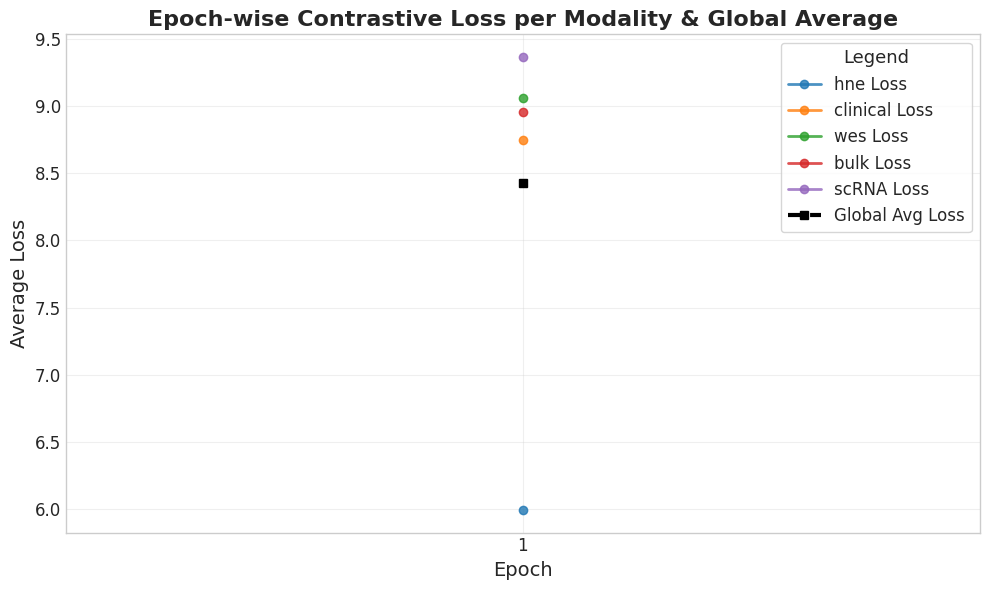

Saved animation to emb_mme_animation.gif
Saved animation to emb_by_modality_animation.gif
Saved animation to emb_by_patient_animation.gif


In [16]:
modality_wise_contrastive_learning(mme, 
                                   dataloader, 
                                   EPOCHS_I, 
                                   1e-3, 
                                   modality_optimizers, 
                                   modality_contrastive_loss_fn, 
                                   modality_schedulers,
                                   batch_all=batch_all,
                                   make_gifs=True)

In [17]:
reg_head_cfg = {"layers": [out*len(mme_cfg),512,256,1],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,2],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}

In [18]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
diameter_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": clf_head_cfg}

In [19]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "diameter": diameter_head_cfg,
                  "recurrency":recurrency_head_cfg}}
refinement_cfg = {"emb_size": out*len(mme_cfg),
                "cross_modality_heads": 2,
                "avail_mods_len":5,
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": 0.3,
                "device": device}
clf_targets = ['recurrency']

In [20]:
clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found


In [21]:
EPOCHS_II = 110
base_lr_II = 1e-3
scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_II_cfg = {"T_max":EPOCHS_II,
                    "eta_min":"dynamic"}
# Optimization for Phase II
optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
scheduler_II_cfg["optimizer"] = optimizer_II
if "eta_min" in scheduler_II_cfg.keys():
    if scheduler_II_cfg["eta_min"] == "dynamic":
        scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

clf_targets_dict = {'recurrency':2}#, 'mgmt':3}

EPOCH 1 TOTAL LOSS: 6.0146
EPOCH 2 TOTAL LOSS: 5.2387
EPOCH 3 TOTAL LOSS: 5.0396
EPOCH 4 TOTAL LOSS: 4.6572
EPOCH 5 TOTAL LOSS: 4.7005
EPOCH 6 TOTAL LOSS: 4.7787
EPOCH 7 TOTAL LOSS: 4.5358
EPOCH 8 TOTAL LOSS: 4.2839
EPOCH 9 TOTAL LOSS: 4.2961
EPOCH 10 TOTAL LOSS: 4.4044
EPOCH 11 TOTAL LOSS: 4.3489
EPOCH 12 TOTAL LOSS: 4.2549
EPOCH 13 TOTAL LOSS: 4.2967
EPOCH 14 TOTAL LOSS: 4.0254
EPOCH 15 TOTAL LOSS: 4.1648
EPOCH 16 TOTAL LOSS: 4.2550
EPOCH 17 TOTAL LOSS: 4.4396
EPOCH 18 TOTAL LOSS: 4.4475
EPOCH 19 TOTAL LOSS: 4.7167
EPOCH 20 TOTAL LOSS: 4.5496
EPOCH 21 TOTAL LOSS: 4.5255
EPOCH 22 TOTAL LOSS: 4.5426
EPOCH 23 TOTAL LOSS: 4.4358
EPOCH 24 TOTAL LOSS: 4.4518
EPOCH 25 TOTAL LOSS: 4.5468
EPOCH 26 TOTAL LOSS: 4.3200
EPOCH 27 TOTAL LOSS: 4.2329
EPOCH 28 TOTAL LOSS: 4.2733
EPOCH 29 TOTAL LOSS: 4.4258
EPOCH 30 TOTAL LOSS: 4.3969
EPOCH 31 TOTAL LOSS: 4.4324
EPOCH 32 TOTAL LOSS: 4.3812
EPOCH 33 TOTAL LOSS: 4.4214
EPOCH 34 TOTAL LOSS: 4.4301
EPOCH 35 TOTAL LOSS: 4.5497
EPOCH 36 TOTAL LOSS: 4.3058
E

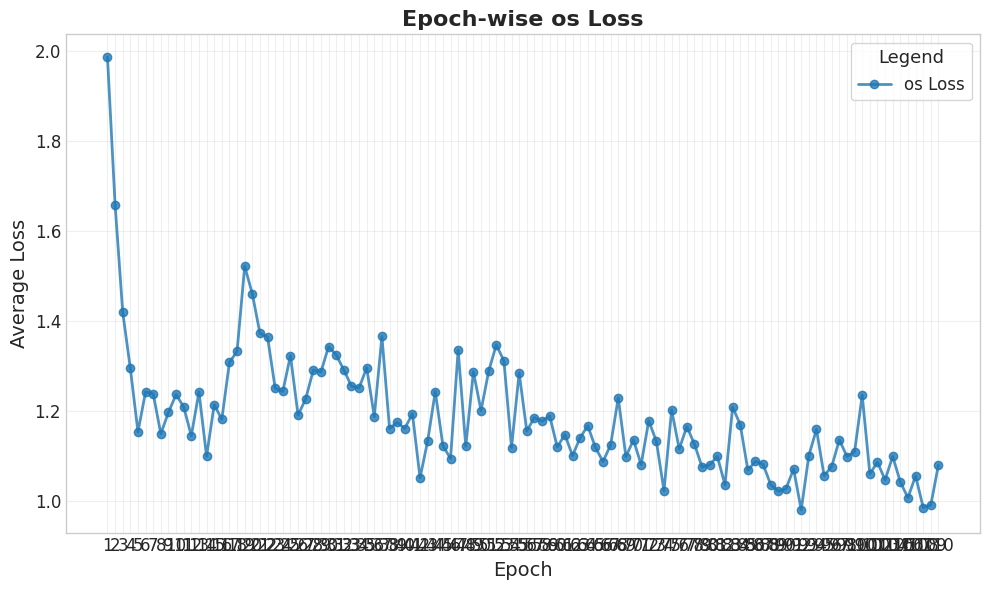

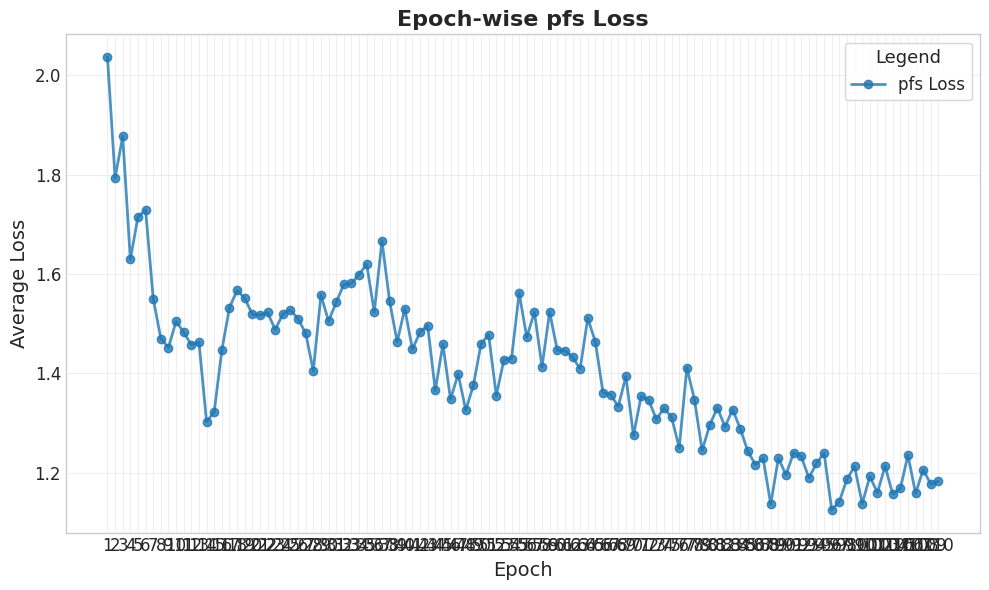

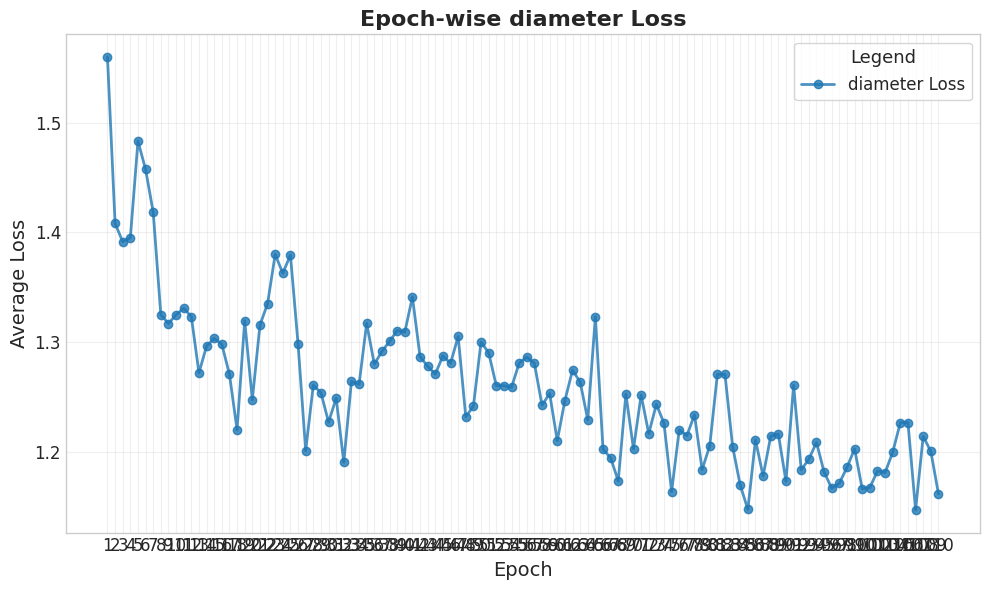

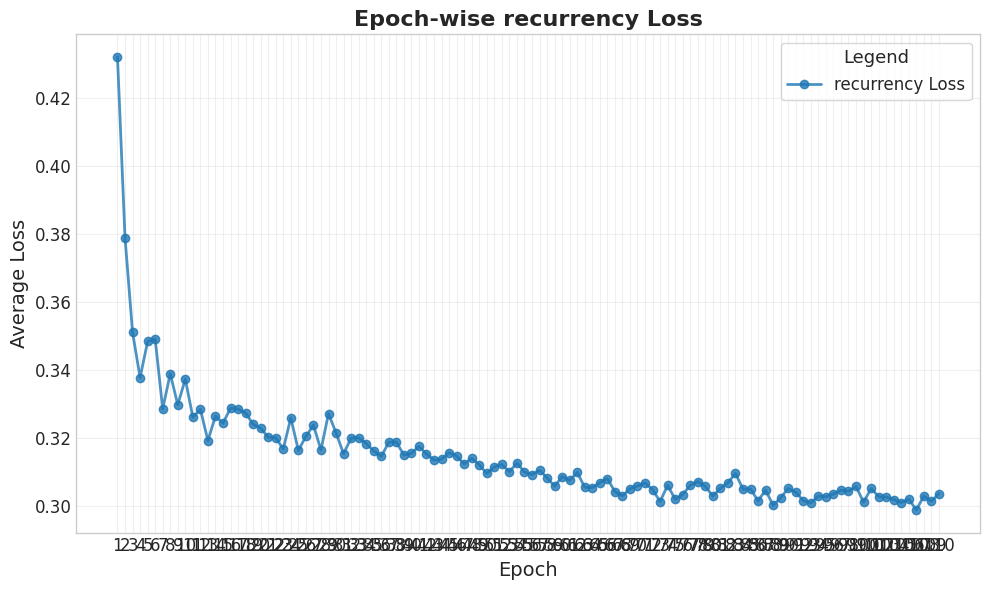

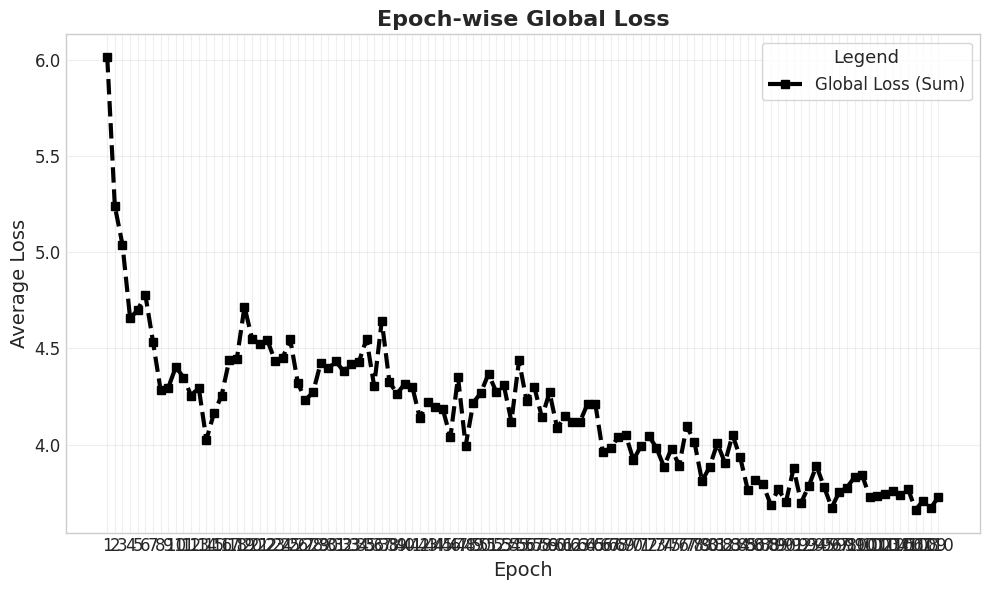

In [22]:
new_predictive_learning(mme, clm, 
                          dataloader,
                          EPOCHS_II, 
                          1e-3, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all,
                          make_gifs=False,
                          )

In [23]:
# Inference on all original patient samples
visualize_inference(batch_all, mme, clm)

NameError: name 'batch_all' is not defined

In [ ]:
visualize_embeddings(true_patient_embeddings, 'umap', cluster_method='optics', return_fig=True)
plt.show()

# **Saving trained models**

In [ ]:
from gbmhackathon.utils.model_saving import save_model, load_model

## To see what we saved

In [ ]:
mme

In [ ]:
mme_path, mme_cfg_path = save_model(mme, '../saved_models/new_framework_mme.ckpt')

In [ ]:
clm

In [ ]:
clm_path, clm_cfg_path = save_model(clm, '../saved_models/new_framework_clm.ckpt')

## Load models back again just to check we retrieve the expected objects

In [ ]:
loaded_mme = load_model(MultiModalEncoder, mme_path, mme_cfg_path, device, training=False)

In [ ]:
loaded_mme

In [ ]:
loaded_clm = load_model(ClinicalLinkageModule, clm_path, clm_cfg_path, device, training=False)

In [ ]:
loaded_clm